<a href="https://colab.research.google.com/github/AdityaMitra5102/ML-TImeSeries/blob/main/assignment1_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Term Project: Statistical & Frequency-Domain Analysis
**Dataset:** SSH Anomaly Detection (`mdwiraputradananjaya/ssh-anomaly-dataset`)
**Goal:** Characterise brute-force vs normal SSH traffic before modelling

## 0. Setup

In [ ]:
import kagglehub, glob, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats, signal
from scipy.fft import fft, fftfreq
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pywt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

## 1. Load & Prepare

In [ ]:
path = kagglehub.dataset_download('mdwiraputradananjaya/ssh-anomaly-dataset')
df = pd.concat([pd.read_csv(f) for f in glob.glob(os.path.join(path, '**/*.csv'), recursive=True)], ignore_index=True)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)
df['label_bin'] = (df['label'].str.lower() != 'normal').astype(int)

print(df.shape)
print(df['label'].value_counts())

100%|██████████| 298k/298k [00:00<00:00, 855kB/s]

Extracting files...


(41825, 8)
label
brute_force                     37749
normal                           3707
brute_force_connection_issue      367
config_anomaly                      2
Name: count, dtype: int64


In [ ]:
# Resample to 1-second counts — the actual time series we analyse
df_bf  = df[df['label_bin'] == 1].set_index('timestamp')
df_nom = df[df['label_bin'] == 0].set_index('timestamp')

# Full time index spanning entire dataset
full_idx = pd.date_range(df['timestamp'].min().floor('s'),
                          df['timestamp'].max().ceil('s'), freq='1s')

ts_bf  = df_bf.resample('1s').size().reindex(full_idx, fill_value=0).rename('brute_force')
ts_nom = df_nom.resample('1s').size().reindex(full_idx, fill_value=0).rename('normal')

print(f'Series length: {len(ts_bf)} seconds  ({len(ts_bf)/3600:.1f} hours)')
print(f'Brute force — total events: {ts_bf.sum()},  max/s: {ts_bf.max()}')
print(f'Normal       — total events: {ts_nom.sum()}, max/s: {ts_nom.max()}')

Series length: 259193 seconds  (72.0 hours)
Brute force — total events: 38118,  max/s: 5
Normal       — total events: 3707, max/s: 2


---
## 2. Descriptive Statistics

In [ ]:
def desc_stats(series, name):
    s = series.values
    return {
        'Series':    name,
        'Mean':      round(np.mean(s), 4),
        'Std':       round(np.std(s), 4),
        'Variance':  round(np.var(s), 4),
        'Min':       int(np.min(s)),
        'Max':       int(np.max(s)),
        'Median':    round(np.median(s), 4),
        'Skewness':  round(stats.skew(s), 4),
        'Kurtosis':  round(stats.kurtosis(s), 4),  # excess kurtosis
        'IQR':       round(np.percentile(s, 75) - np.percentile(s, 25), 4),
        'Non-zero %': round(100 * np.mean(s > 0), 2),
    }

stats_df = pd.DataFrame([desc_stats(ts_bf, 'Brute Force'),
                          desc_stats(ts_nom, 'Normal')])
stats_df.set_index('Series', inplace=True)
print(stats_df.T.to_string())

Series      Brute Force   Normal
Mean             0.1471   0.0143
Std              0.4750   0.1192
Variance         0.2256   0.0142
Min              0.0000   0.0000
Max              5.0000   2.0000
Median           0.0000   0.0000
Skewness         3.6477   8.2836
Kurtosis        14.2632  67.7454
IQR              0.0000   0.0000
Non-zero %      10.4100   1.4200


In [ ]:
# Inter-arrival times per class
for name, grp in [('Brute Force', df[df['label_bin']==1]), ('Normal', df[df['label_bin']==0])]:
    iats = grp['timestamp'].diff().dt.total_seconds().dropna()
    print(f"{name} IAT — mean: {iats.mean():.3f}s  std: {iats.std():.3f}s  "
          f"median: {iats.median():.3f}s  skew: {stats.skew(iats):.3f}")

Brute Force IAT — mean: 5.933s  std: 445.235s  median: 0.800s  skew: 136.408
Normal IAT — mean: 69.938s  std: 180.628s  median: 41.400s  skew: 19.069


---
## 3. Temporal Patterns & Trends

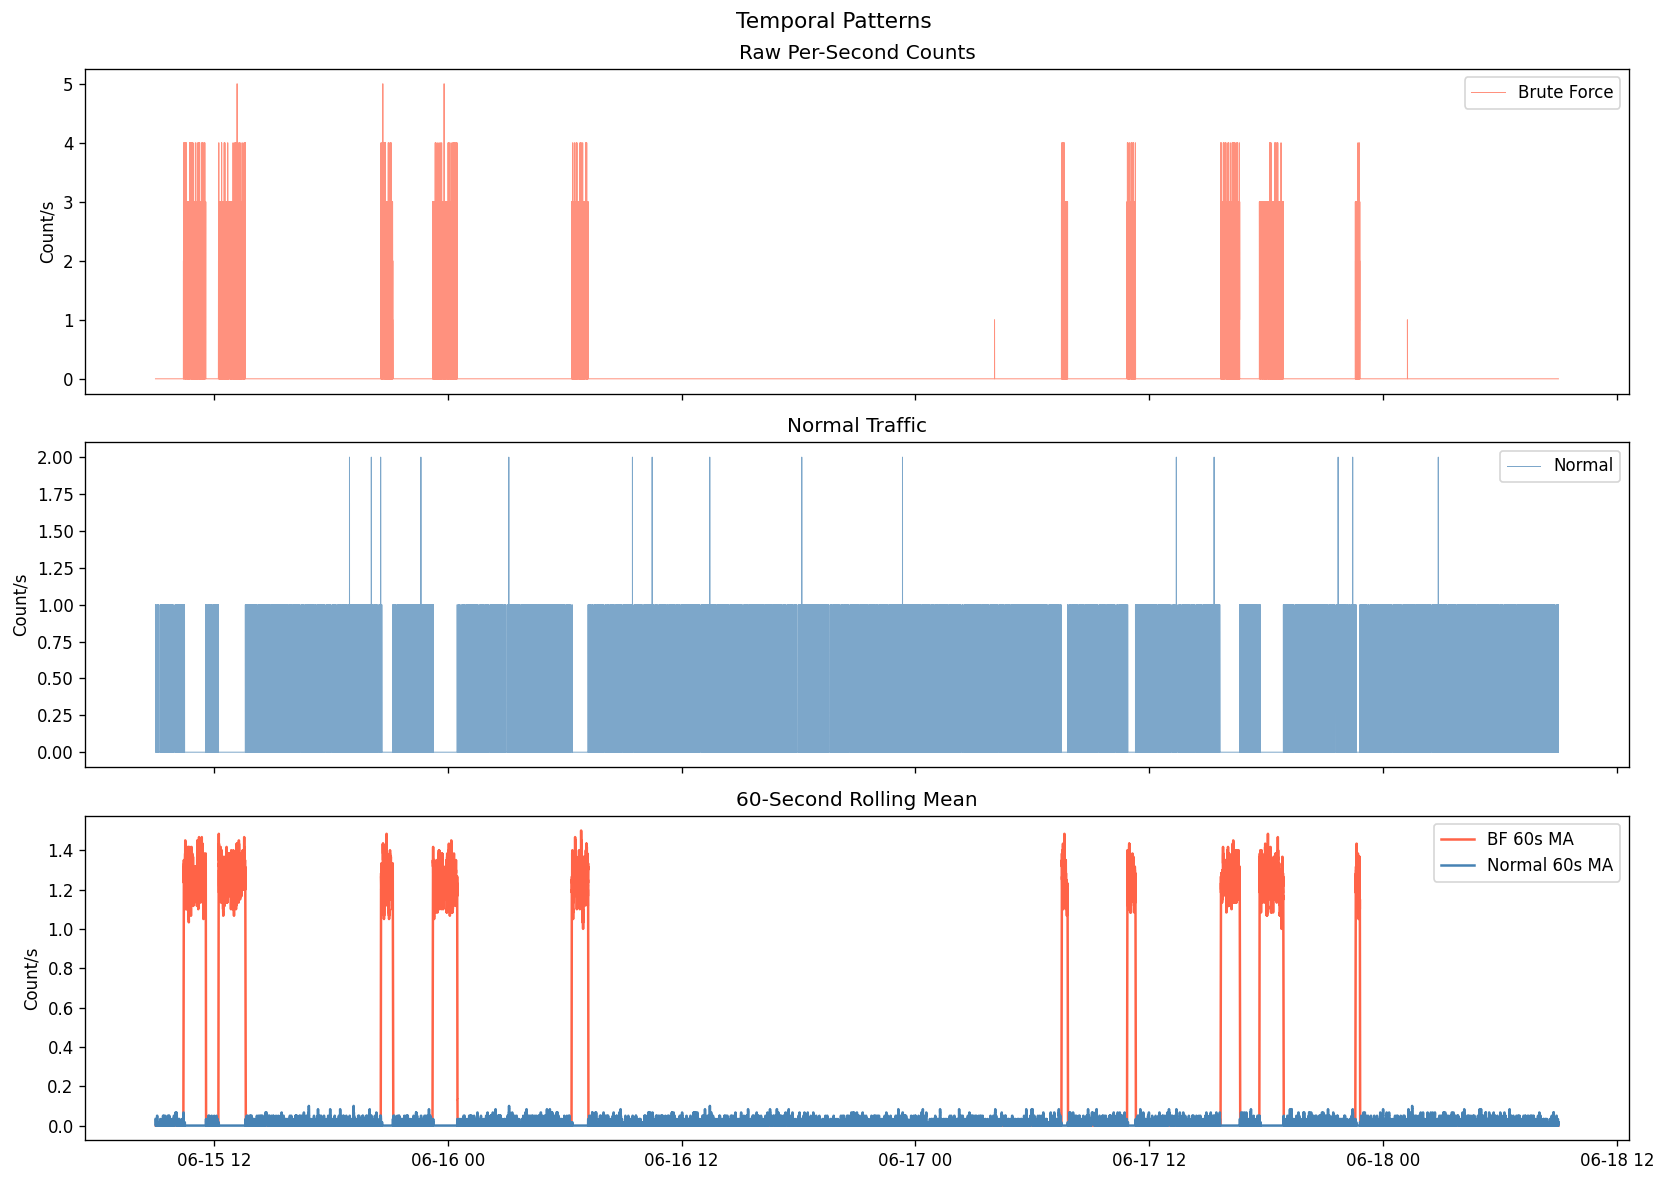

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Raw 1-second counts
axes[0].plot(ts_bf.index, ts_bf.values, color='tomato', alpha=0.7, linewidth=0.6, label='Brute Force')
axes[0].set_ylabel('Count/s'); axes[0].set_title('Raw Per-Second Counts')
axes[0].legend()

axes[1].plot(ts_nom.index, ts_nom.values, color='steelblue', alpha=0.7, linewidth=0.6, label='Normal')
axes[1].set_ylabel('Count/s'); axes[1].set_title('Normal Traffic')
axes[1].legend()

# 60-second rolling mean to show trends
axes[2].plot(ts_bf.index, ts_bf.rolling(60).mean(), color='tomato', label='BF 60s MA')
axes[2].plot(ts_nom.index, ts_nom.rolling(60).mean(), color='steelblue', label='Normal 60s MA')
axes[2].set_ylabel('Count/s'); axes[2].set_title('60-Second Rolling Mean')
axes[2].legend()

plt.suptitle('Temporal Patterns', fontsize=13)
plt.tight_layout()
plt.show()

---
## 4. Stationarity Assessment

In [ ]:
def stationarity_tests(series, name):
    print(f'\n=== {name} ===')

    # ADF — H0: unit root (non-stationary)
    adf = adfuller(series.values, autolag='AIC')
    print(f'ADF  stat={adf[0]:.4f}  p={adf[1]:.4f}  '
          f'=> {"STATIONARY" if adf[1] < 0.05 else "NON-STATIONARY"} (p<0.05)')

    # KPSS — H0: stationary
    kp = kpss(series.values, regression='c', nlags='auto')
    print(f'KPSS stat={kp[0]:.4f}  p={kp[1]:.4f}  '
          f'=> {"NON-STATIONARY" if kp[1] < 0.05 else "STATIONARY"} (p<0.05)')

stationarity_tests(ts_bf, 'Brute Force (raw counts)')
stationarity_tests(ts_nom, 'Normal (raw counts)')


=== Brute Force (raw counts) ===
ADF  stat=-7.1635  p=0.0000  => STATIONARY (p<0.05)
KPSS stat=3.2869  p=0.0100  => NON-STATIONARY (p<0.05)

=== Normal (raw counts) ===
ADF  stat=-102.0594  p=0.0000  => STATIONARY (p<0.05)
KPSS stat=1.7481  p=0.0100  => NON-STATIONARY (p<0.05)


---
## 5. ACF & PACF

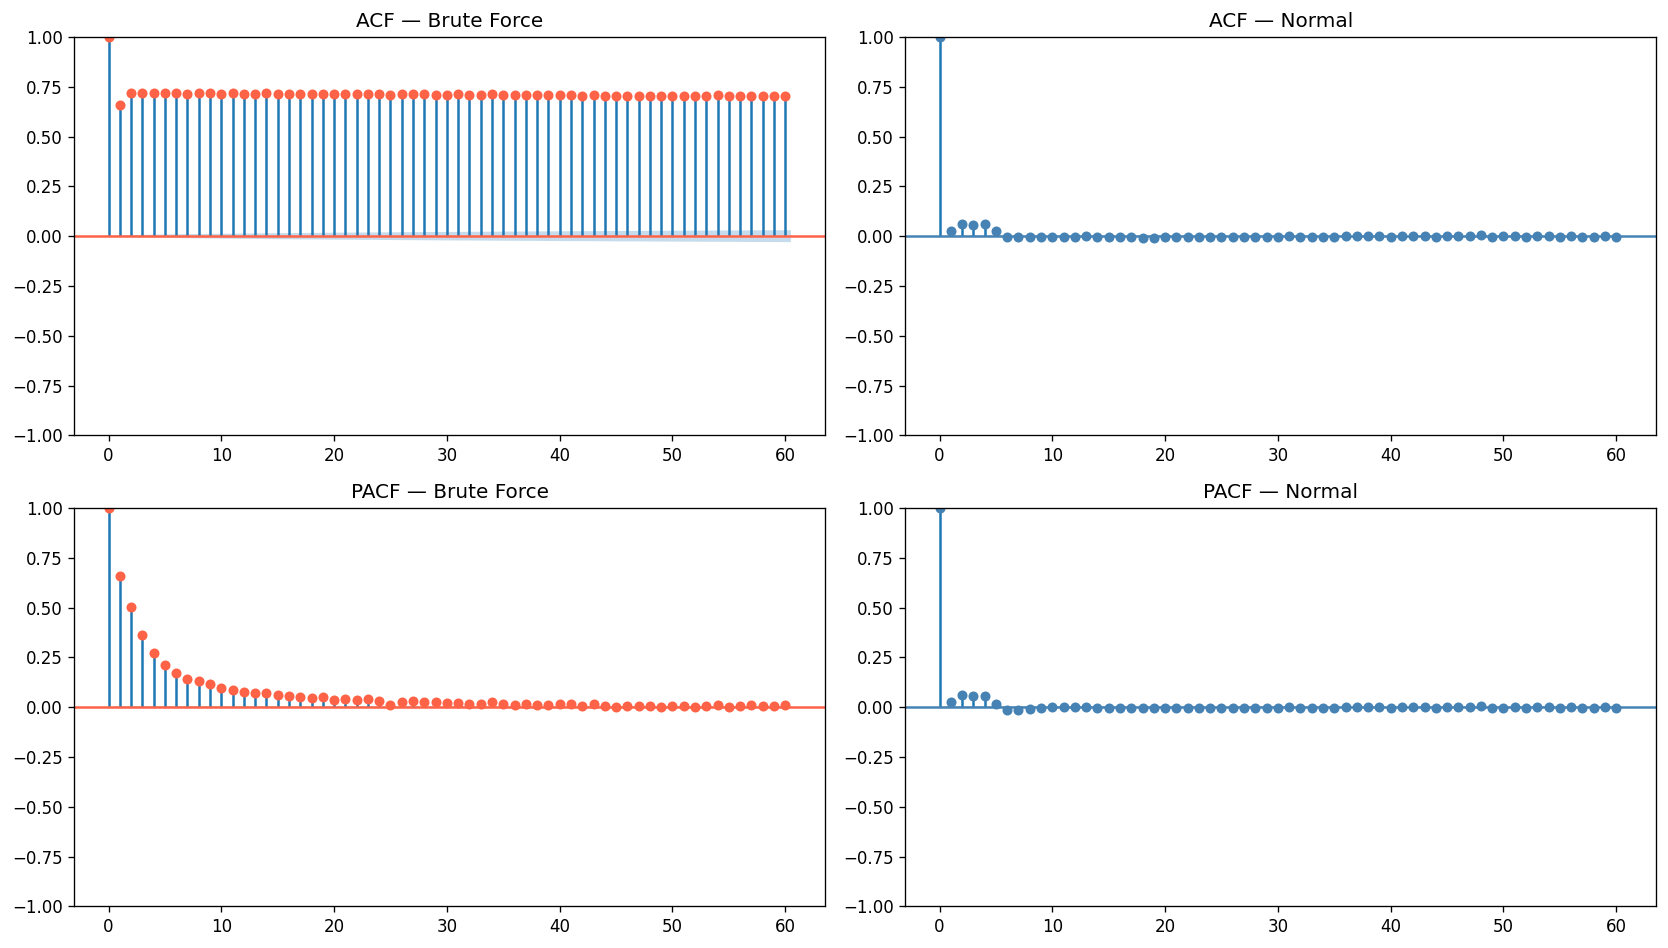

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plot_acf(ts_bf,  lags=60, ax=axes[0,0], title='ACF — Brute Force',  color='tomato')
plot_acf(ts_nom, lags=60, ax=axes[0,1], title='ACF — Normal',        color='steelblue')
plot_pacf(ts_bf,  lags=60, ax=axes[1,0], title='PACF — Brute Force', color='tomato')
plot_pacf(ts_nom, lags=60, ax=axes[1,1], title='PACF — Normal',      color='steelblue')

plt.tight_layout()
plt.show()

---
## 6. Seasonality, Trend, Structural Breaks (STL + CUSUM)

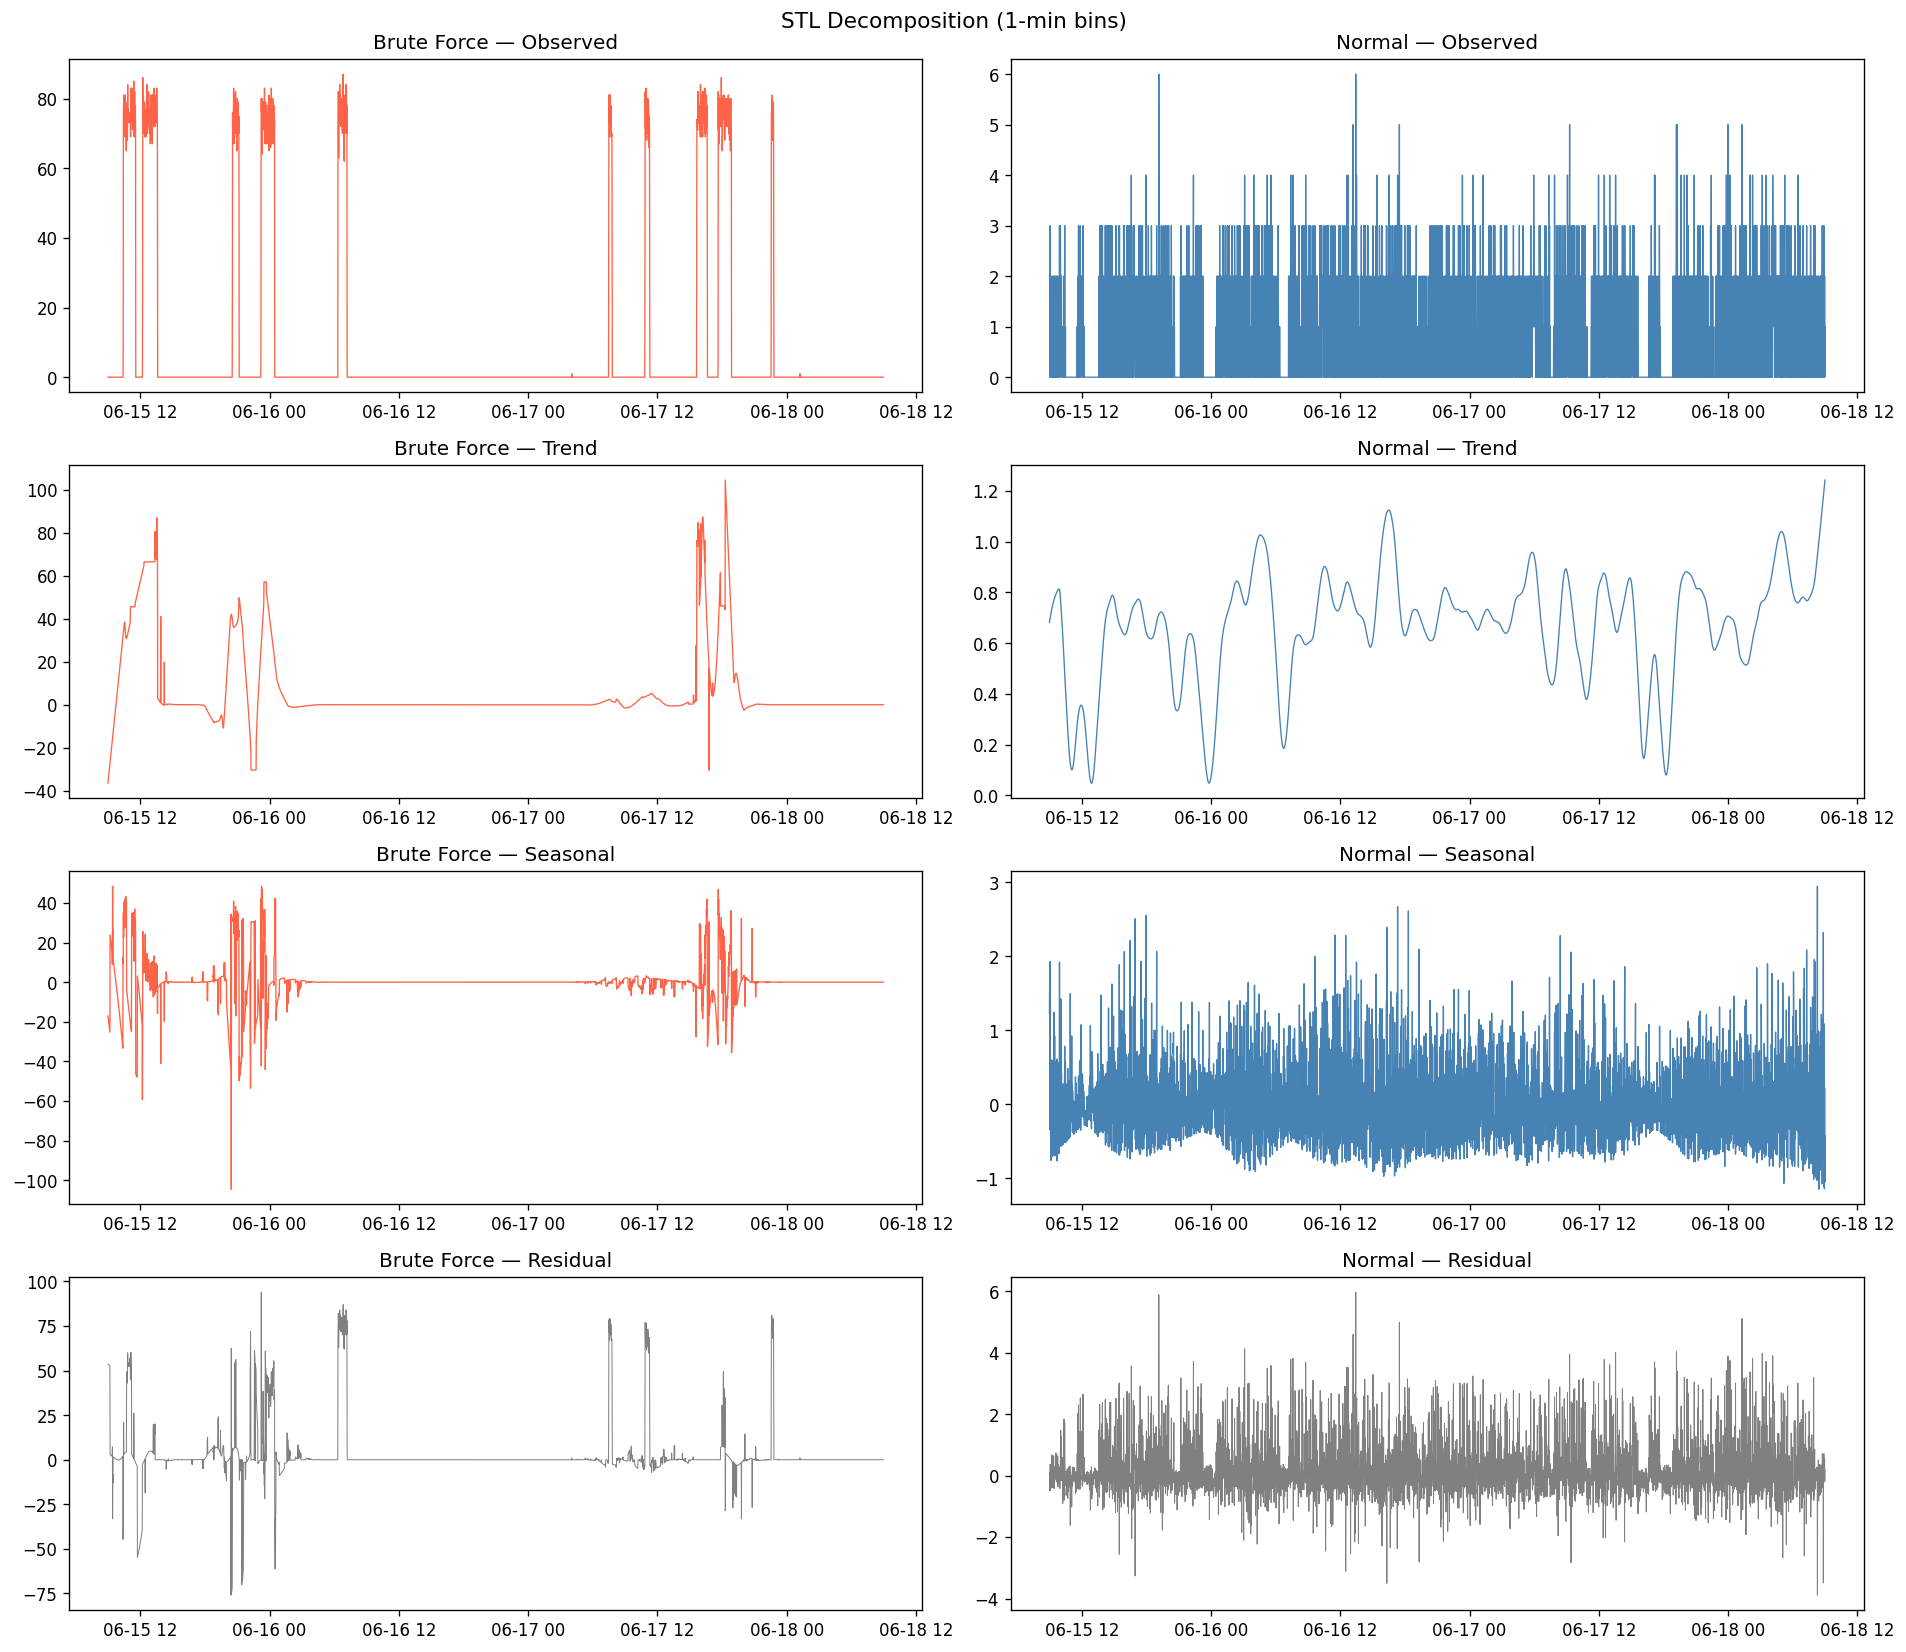

In [ ]:
# Downsample to 1-minute for STL
ts_bf_min  = ts_bf.resample('1min').sum()
ts_nom_min = ts_nom.resample('1min').sum()

fig, axes = plt.subplots(4, 2, figsize=(16, 14))

for i, (ts, name, color) in enumerate([
    (ts_bf_min, 'Brute Force', 'tomato'),
    (ts_nom_min, 'Normal', 'steelblue')
]):
    stl = STL(ts, period=60, robust=True)
    res = stl.fit()

    axes[0, i].plot(res.observed,  color=color, linewidth=0.8); axes[0, i].set_title(f'{name} — Observed')
    axes[1, i].plot(res.trend,     color=color, linewidth=0.8); axes[1, i].set_title(f'{name} — Trend')
    axes[2, i].plot(res.seasonal,  color=color, linewidth=0.8); axes[2, i].set_title(f'{name} — Seasonal')
    axes[3, i].plot(res.resid,     color='gray', linewidth=0.6); axes[3, i].set_title(f'{name} — Residual')

plt.suptitle('STL Decomposition (1-min bins)', fontsize=13)
plt.tight_layout()
plt.show()

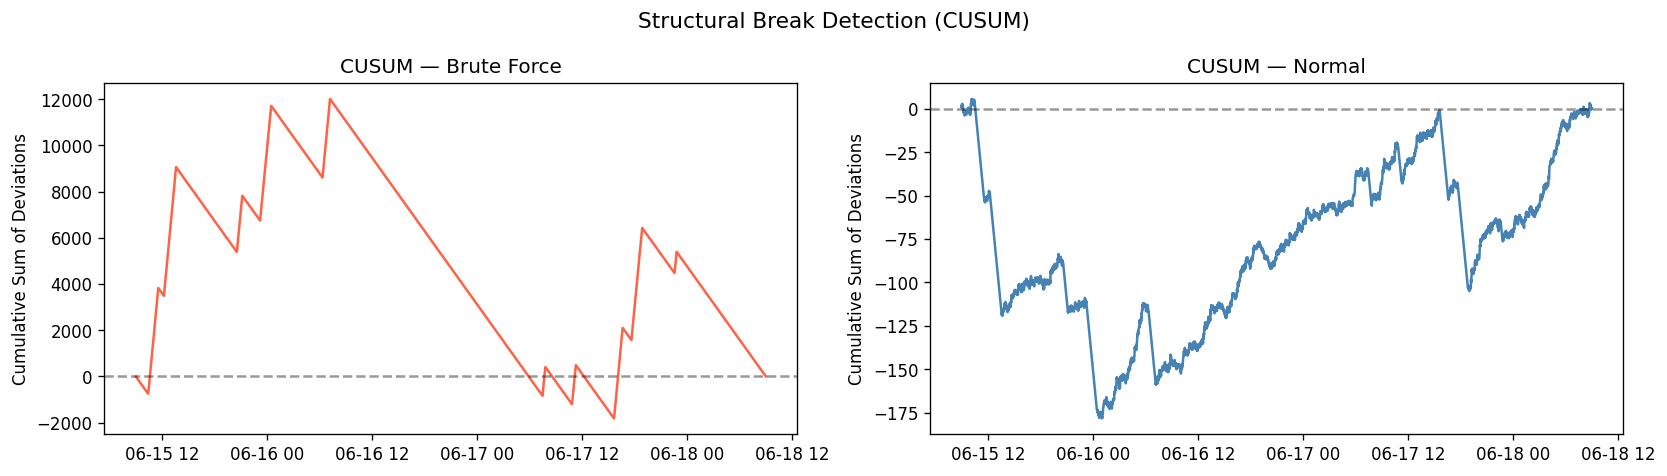

In [ ]:
# CUSUM for structural breaks
def cusum(series):
    s = series.values.astype(float)
    mean = s.mean()
    return np.cumsum(s - mean)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, ts, name, color in [
    (axes[0], ts_bf_min,  'Brute Force', 'tomato'),
    (axes[1], ts_nom_min, 'Normal',      'steelblue')
]:
    c = cusum(ts)
    ax.plot(ts.index, c, color=color)
    ax.axhline(0, color='black', linestyle='--', alpha=0.4)
    ax.set_title(f'CUSUM — {name}')
    ax.set_ylabel('Cumulative Sum of Deviations')

plt.suptitle('Structural Break Detection (CUSUM)', fontsize=13)
plt.tight_layout()
plt.show()

---
## 7. Distributional Analysis & Outlier Detection

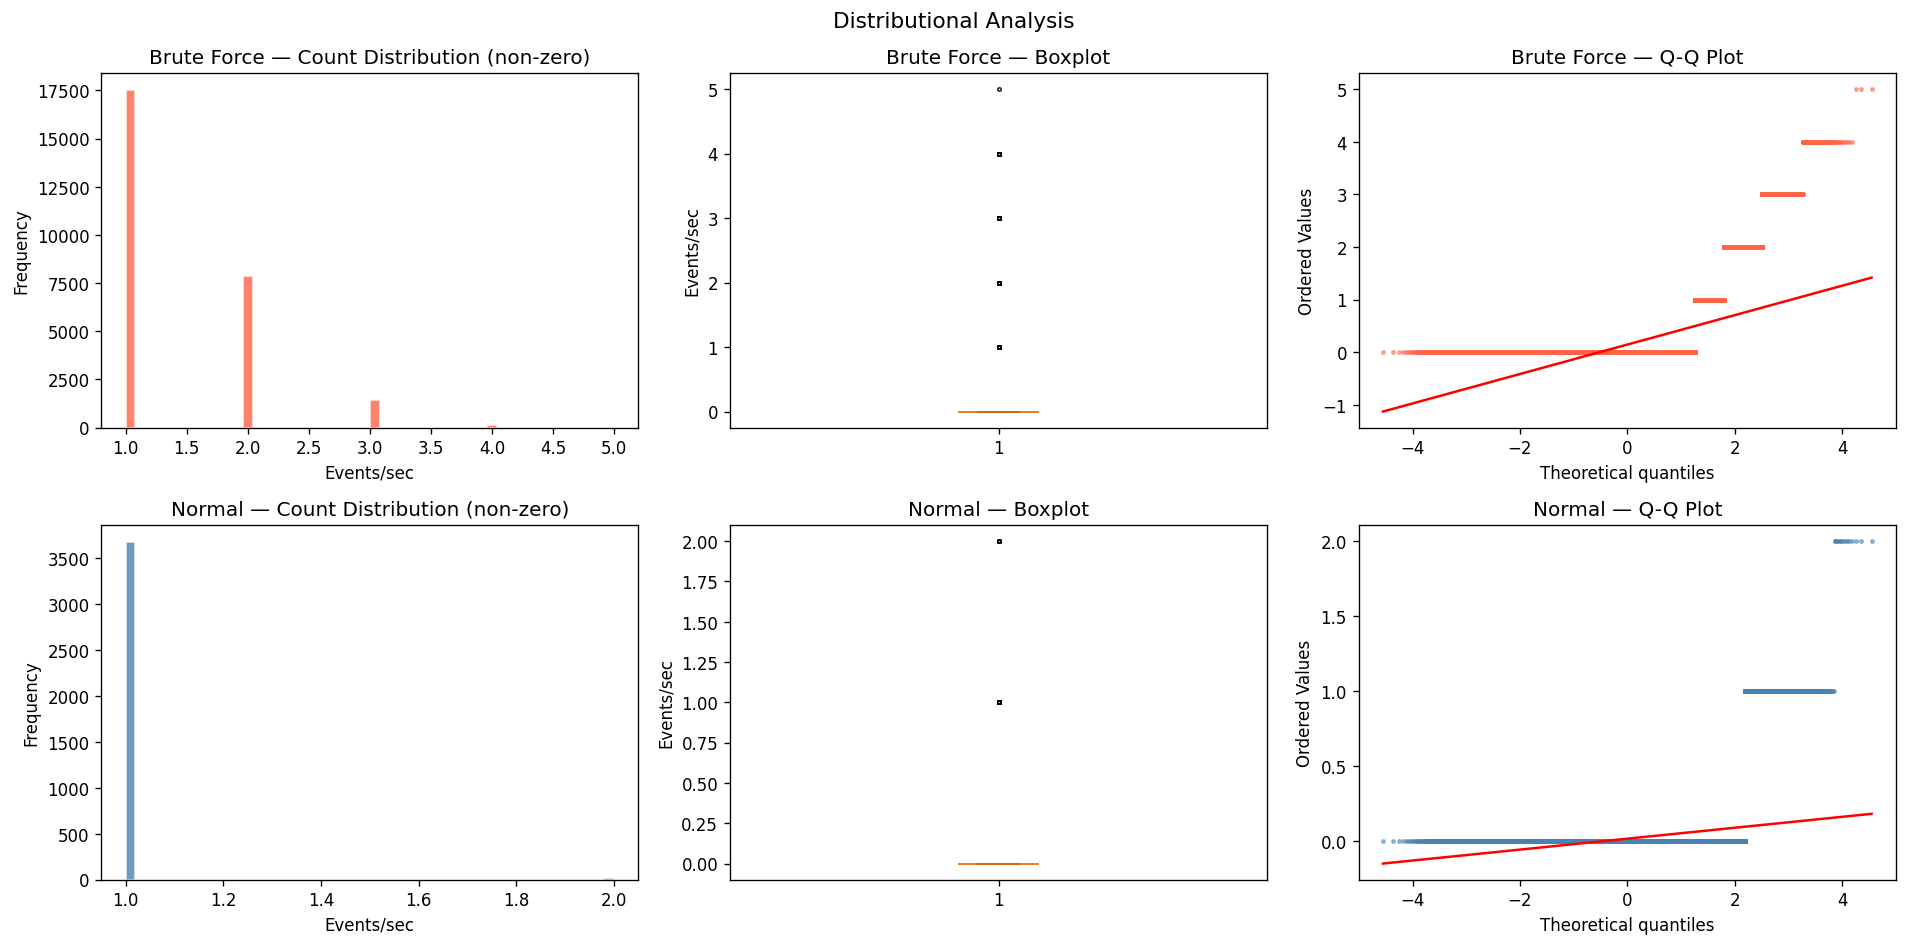

Brute Force: 26976 outliers (10.41%)  upper fence: 0.00
Normal: 3692 outliers (1.42%)  upper fence: 0.00


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for i, (ts, name, color) in enumerate([
    (ts_bf,  'Brute Force', 'tomato'),
    (ts_nom, 'Normal',      'steelblue')
]):
    v = ts.values

    # Histogram
    axes[i, 0].hist(v[v > 0], bins=50, color=color, alpha=0.8, edgecolor='white')
    axes[i, 0].set_title(f'{name} — Count Distribution (non-zero)')
    axes[i, 0].set_xlabel('Events/sec'); axes[i, 0].set_ylabel('Frequency')

    # Boxplot
    axes[i, 1].boxplot(v, patch_artist=True,
                        boxprops=dict(facecolor=color, alpha=0.6),
                        flierprops=dict(marker='o', markersize=2, alpha=0.4))
    axes[i, 1].set_title(f'{name} — Boxplot')
    axes[i, 1].set_ylabel('Events/sec')

    # Q-Q plot
    stats.probplot(v, dist='norm', plot=axes[i, 2])
    axes[i, 2].set_title(f'{name} — Q-Q Plot')
    axes[i, 2].get_lines()[0].set(color=color, alpha=0.5, markersize=2)

plt.suptitle('Distributional Analysis', fontsize=13)
plt.tight_layout()
plt.show()

# IQR outlier count
for ts, name in [(ts_bf, 'Brute Force'), (ts_nom, 'Normal')]:
    q1, q3 = ts.quantile(0.25), ts.quantile(0.75)
    iqr = q3 - q1
    outliers = ts[(ts < q1 - 1.5*iqr) | (ts > q3 + 1.5*iqr)]
    print(f'{name}: {len(outliers)} outliers ({100*len(outliers)/len(ts):.2f}%)  upper fence: {q3 + 1.5*iqr:.2f}')

---
## 8. Power Spectral Density (Welch)

Brute Force dominant freqs (Hz): [np.float64(0.47656), np.float64(0.49609), np.float64(0.46387), np.float64(0.48242), np.float64(0.48828)]
  Periods (s): [np.float64(2.1), np.float64(2.0), np.float64(2.2), np.float64(2.1), np.float64(2.0)]
Normal dominant freqs (Hz): [np.float64(0.00391), np.float64(0.01367), np.float64(0.01758), np.float64(0.02734), np.float64(0.02344)]
  Periods (s): [np.float64(256.0), np.float64(73.1), np.float64(56.9), np.float64(36.6), np.float64(42.7)]


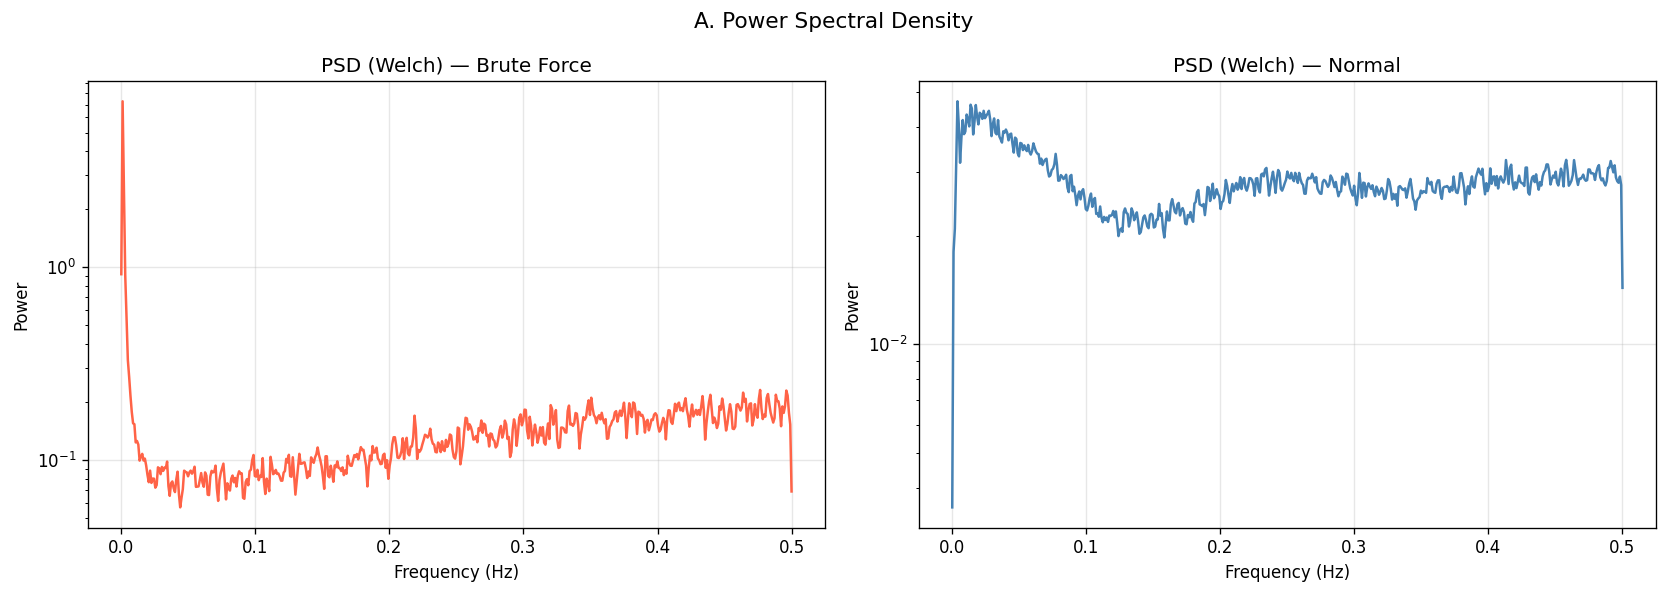

In [ ]:
FS = 1.0  # 1 Hz sampling (1 sample per second)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, ts, name, color in [
    (axes[0], ts_bf,  'Brute Force', 'tomato'),
    (axes[1], ts_nom, 'Normal',      'steelblue')
]:
    f, pxx = signal.welch(ts.values, fs=FS, nperseg=1024)
    ax.semilogy(f, pxx, color=color)
    ax.set_title(f'PSD (Welch) — {name}')
    ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('Power')
    ax.grid(True, alpha=0.3)

    # Top 5 dominant frequencies
    peaks, _ = signal.find_peaks(pxx[1:], height=np.percentile(pxx, 90))
    top = sorted(peaks, key=lambda x: pxx[x+1], reverse=True)[:5]
    print(f'{name} dominant freqs (Hz): {[round(f[p+1], 5) for p in top]}')
    print(f'  Periods (s): {[round(1/f[p+1], 1) if f[p+1] > 0 else "inf" for p in top]}')

plt.suptitle('A. Power Spectral Density', fontsize=13)
plt.tight_layout()
plt.show()

---
## 9. FFT & Harmonic Structure

Brute Force fundamental: 0.00003 Hz (period=32399.1s)
  Expected harmonics: [np.float64(0.0001), np.float64(0.0001), np.float64(0.0001)]
Normal fundamental: 0.00003 Hz (period=37027.6s)
  Expected harmonics: [np.float64(0.0001), np.float64(0.0001), np.float64(0.0001)]


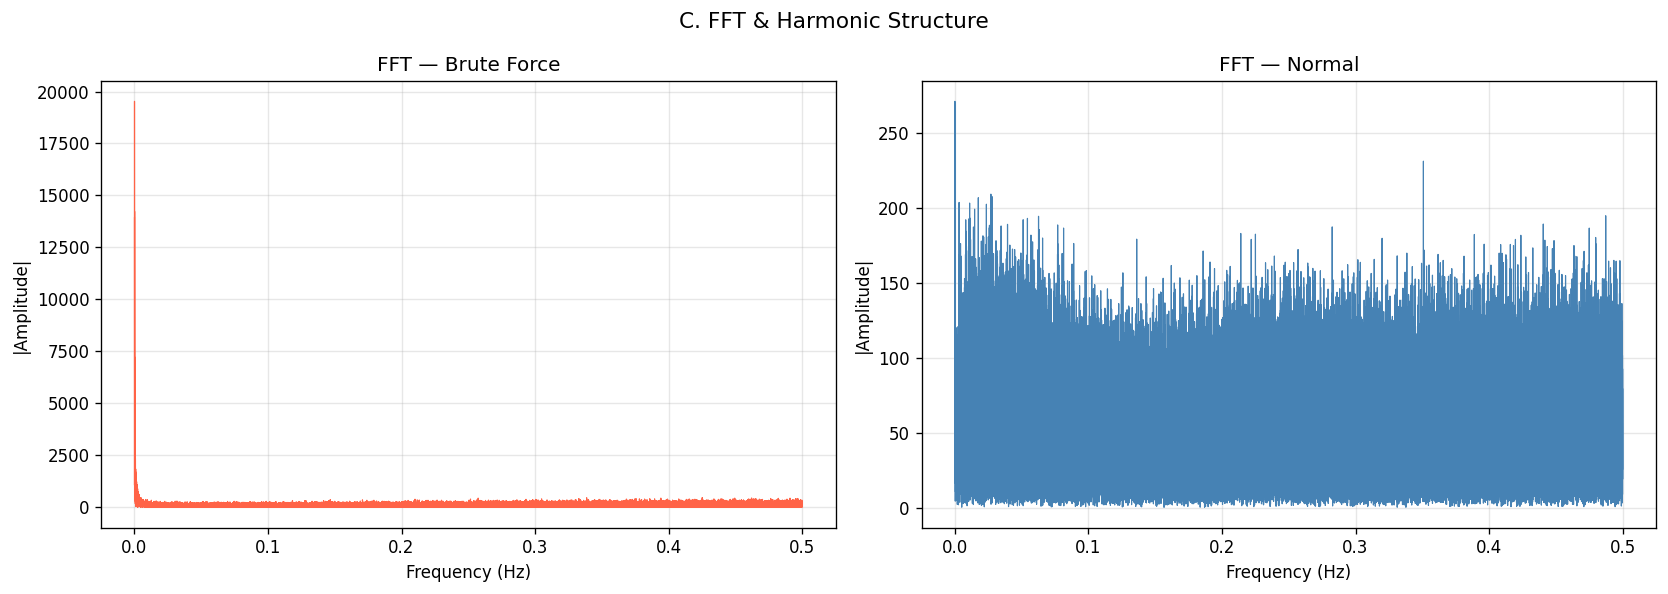

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, ts, name, color in [
    (axes[0], ts_bf,  'Brute Force', 'tomato'),
    (axes[1], ts_nom, 'Normal',      'steelblue')
]:
    N = len(ts)
    yf = fft(ts.values)
    xf = fftfreq(N, d=1.0/FS)

    # Positive frequencies only
    pos = xf > 0
    ax.plot(xf[pos], np.abs(yf[pos]), color=color, linewidth=0.7)
    ax.set_title(f'FFT — {name}')
    ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('|Amplitude|')
    ax.grid(True, alpha=0.3)

    # Harmonic check: find top freq and look for multiples
    amp = np.abs(yf[pos])
    freqs = xf[pos]
    top_f = freqs[np.argmax(amp[1:]) + 1]  # skip DC
    print(f'{name} fundamental: {top_f:.5f} Hz (period={1/top_f:.1f}s)')
    harmonics = [freqs[np.argmin(np.abs(freqs - top_f*k))] for k in [2, 3, 4]]
    print(f'  Expected harmonics: {[round(h, 4) for h in harmonics]}')

plt.suptitle('C. FFT & Harmonic Structure', fontsize=13)
plt.tight_layout()
plt.show()

---
## 10. STFT Spectrogram

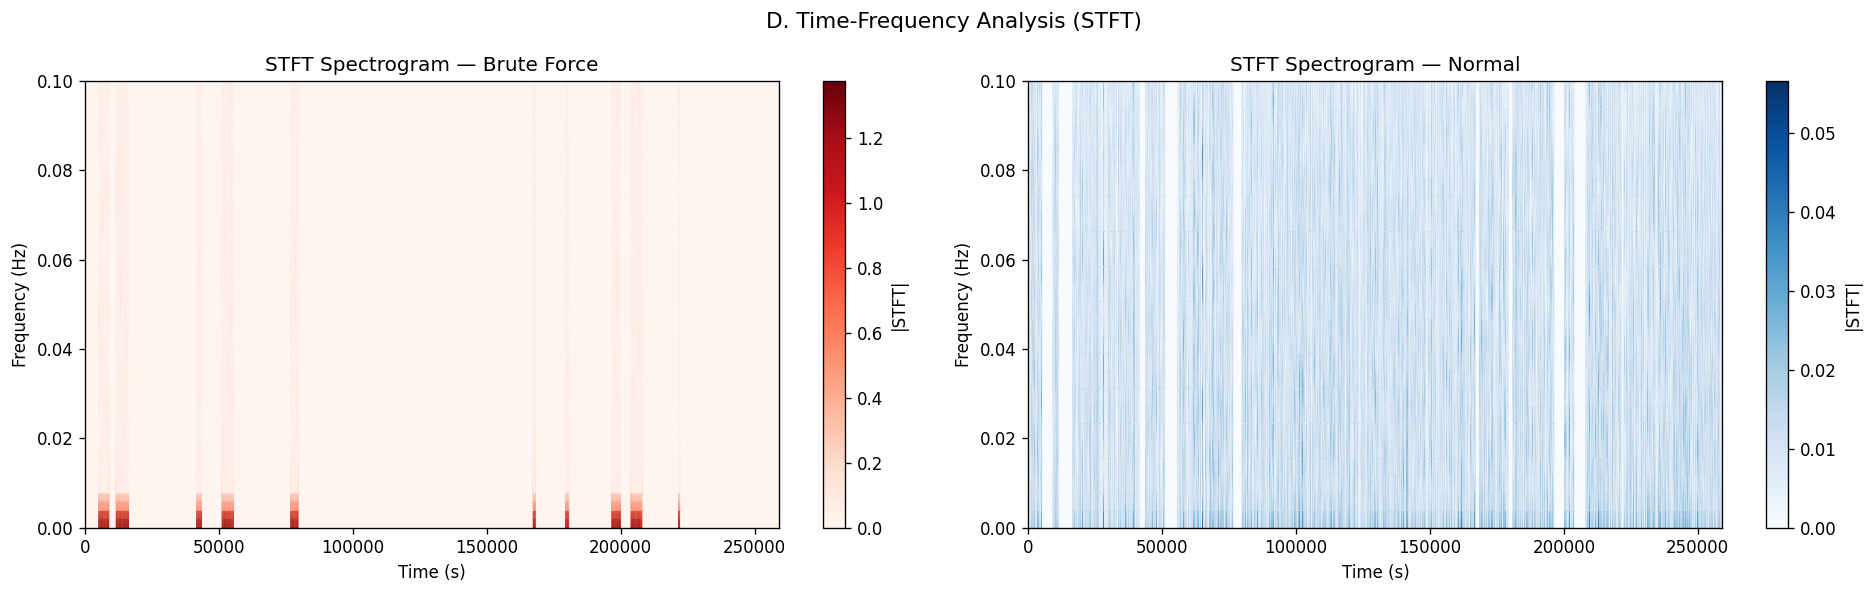

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, ts, name, cmap in [
    (axes[0], ts_bf,  'Brute Force', 'Reds'),
    (axes[1], ts_nom, 'Normal',      'Blues')
]:
    f, t, Zxx = signal.stft(ts.values, fs=FS, nperseg=256, noverlap=200)
    im = ax.pcolormesh(t, f, np.abs(Zxx), shading='gouraud', cmap=cmap)
    ax.set_title(f'STFT Spectrogram — {name}')
    ax.set_xlabel('Time (s)'); ax.set_ylabel('Frequency (Hz)')
    plt.colorbar(im, ax=ax, label='|STFT|')
    ax.set_ylim(0, 0.1)  # focus on low frequencies where signal lives

plt.suptitle('D. Time-Frequency Analysis (STFT)', fontsize=13)
plt.tight_layout()
plt.show()

---
## 11. Wavelet Multi-Resolution Analysis

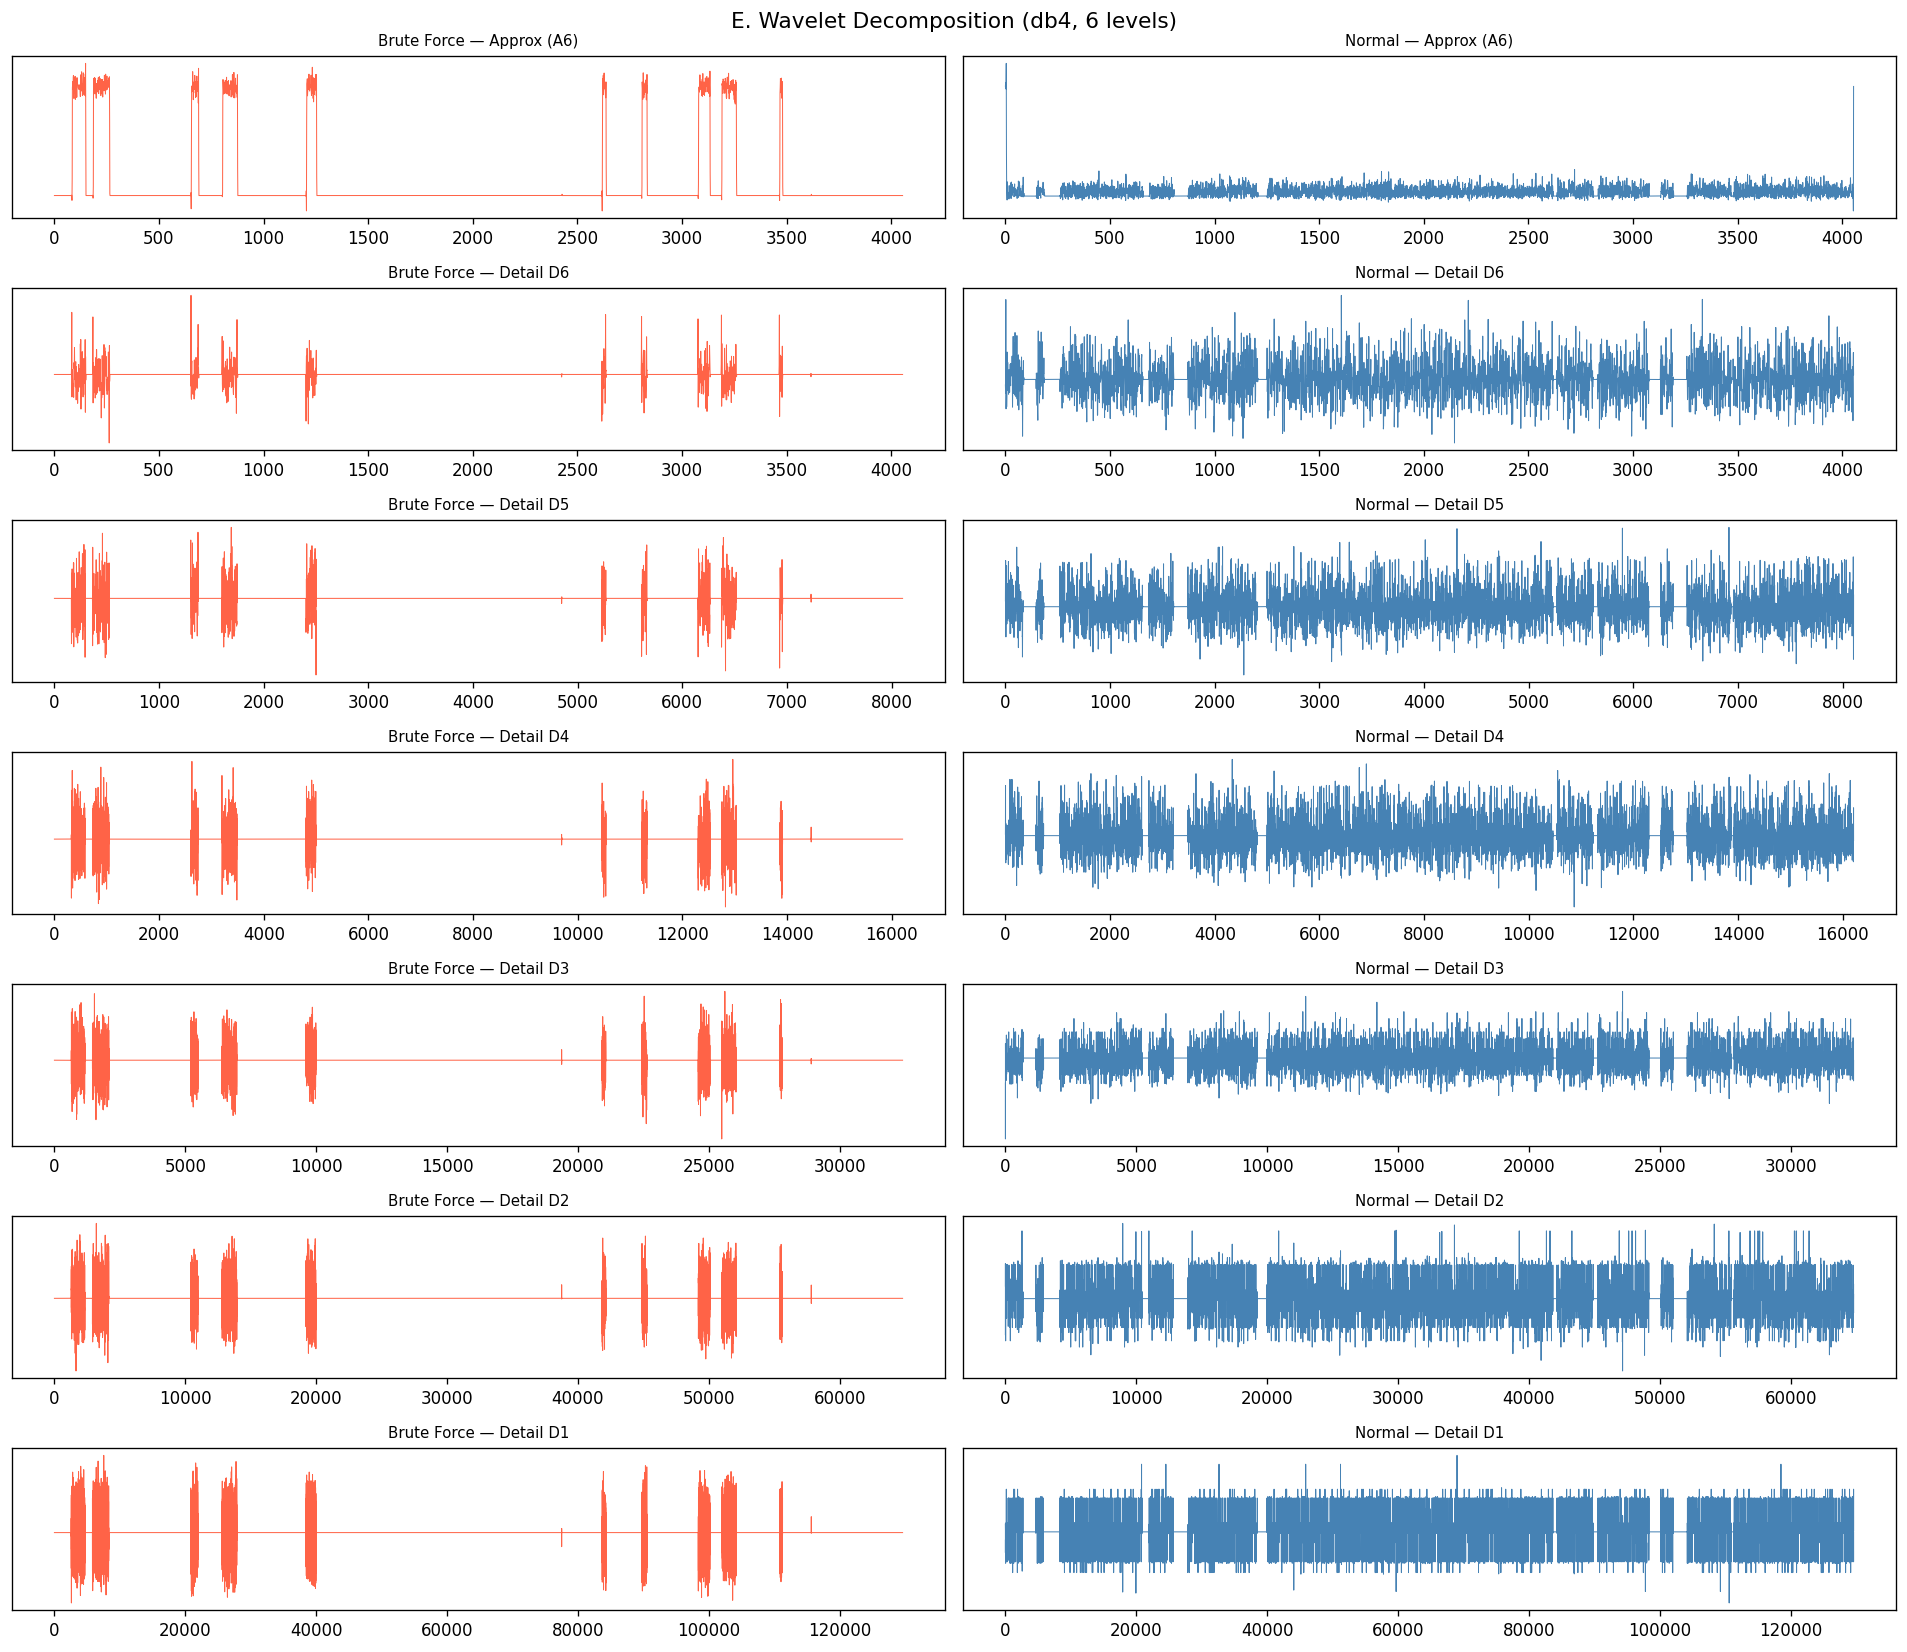


Brute Force wavelet energy distribution:
  A6: 74.3%
  D6: 0.4%
  D5: 0.5%
  D4: 1.0%
  D3: 2.1%
  D2: 5.6%
  D1: 16.1%

Normal wavelet energy distribution:
  A6: 4.8%
  D6: 2.2%
  D5: 4.4%
  D4: 7.8%
  D3: 11.5%
  D2: 21.5%
  D1: 47.7%


In [ ]:
WAVELET = 'db4'
LEVELS  = 6

fig, axes = plt.subplots(LEVELS + 1, 2, figsize=(16, 14), sharex=False)

for col, (ts, name, color) in enumerate([
    (ts_bf,  'Brute Force', 'tomato'),
    (ts_nom, 'Normal',      'steelblue')
]):
    coeffs = pywt.wavedec(ts.values, WAVELET, level=LEVELS)
    labels = ['Approx (A6)'] + [f'Detail D{LEVELS - i}' for i in range(LEVELS)]

    for row, (c, label) in enumerate(zip(coeffs, labels)):
        axes[row, col].plot(c, color=color, linewidth=0.6)
        axes[row, col].set_title(f'{name} — {label}', fontsize=9)
        axes[row, col].set_yticks([])

plt.suptitle(f'E. Wavelet Decomposition ({WAVELET}, {LEVELS} levels)', fontsize=13)
plt.tight_layout()
plt.show()

# Energy per level
for ts, name in [(ts_bf, 'Brute Force'), (ts_nom, 'Normal')]:
    coeffs = pywt.wavedec(ts.values, WAVELET, level=LEVELS)
    energies = [np.sum(c**2) for c in coeffs]
    total = sum(energies)
    labels = ['A6'] + [f'D{LEVELS-i}' for i in range(LEVELS)]
    print(f'\n{name} wavelet energy distribution:')
    for l, e in zip(labels, energies):
        print(f'  {l}: {100*e/total:.1f}%')

---
## 12. Frequency-Domain Features

In [ ]:
def spectral_features(ts, fs=1.0, name=''):
    x = ts.values.astype(float)
    f, pxx = signal.welch(x, fs=fs, nperseg=1024)

    # Skip DC for most features
    f_nz, p_nz = f[1:], pxx[1:]
    p_norm = p_nz / p_nz.sum()

    # Spectral centroid
    centroid = np.sum(f_nz * p_norm)

    # Spectral bandwidth
    bandwidth = np.sqrt(np.sum(((f_nz - centroid)**2) * p_norm))

    # Spectral entropy
    entropy = -np.sum(p_norm * np.log2(p_norm + 1e-12))

    # Spectral roll-off (95% of energy)
    cumsum = np.cumsum(p_nz)
    rolloff_idx = np.searchsorted(cumsum, 0.95 * cumsum[-1])
    rolloff = f_nz[min(rolloff_idx, len(f_nz)-1)]

    # Band power (split into 4 bands)
    bands = [(0.001, 0.01), (0.01, 0.05), (0.05, 0.1), (0.1, 0.5)]
    band_power = {}
    for lo, hi in bands:
        mask = (f_nz >= lo) & (f_nz < hi)
        band_power[f'{lo}-{hi}Hz'] = round(np.sum(p_nz[mask]), 4)

    print(f'\n=== {name} Spectral Features ===')
    print(f'  Spectral Centroid:   {centroid:.5f} Hz  (period={1/centroid:.1f}s)')
    print(f'  Spectral Bandwidth:  {bandwidth:.5f} Hz')
    print(f'  Spectral Entropy:    {entropy:.4f} bits')
    print(f'  Spectral Roll-off:   {rolloff:.5f} Hz  (95% energy below this)')
    print(f'  Band Power:')
    for band, power in band_power.items():
        print(f'    {band}: {power}')

    return dict(centroid=centroid, bandwidth=bandwidth, entropy=entropy,
                rolloff=rolloff, **band_power)

bf_spec  = spectral_features(ts_bf,  name='Brute Force')
nom_spec = spectral_features(ts_nom, name='Normal')


=== Brute Force Spectral Features ===
  Spectral Centroid:   0.24717 Hz  (period=4.0s)
  Spectral Bandwidth:  0.16528 Hz
  Spectral Entropy:    8.4164 bits
  Spectral Roll-off:   0.47949 Hz  (95% energy below this)
  Band Power:
    0.001-0.01Hz: 5.3624
    0.01-0.05Hz: 3.5317
    0.05-0.1Hz: 4.1065
    0.1-0.5Hz: 57.2571

=== Normal Spectral Features ===
  Spectral Centroid:   0.24437 Hz  (period=4.1s)
  Spectral Bandwidth:  0.15051 Hz
  Spectral Entropy:    8.9798 bits
  Spectral Roll-off:   0.47559 Hz  (95% energy below this)
  Band Power:
    0.001-0.01Hz: 0.3284
    0.01-0.05Hz: 1.6439
    0.05-0.1Hz: 1.5601
    0.1-0.5Hz: 10.97


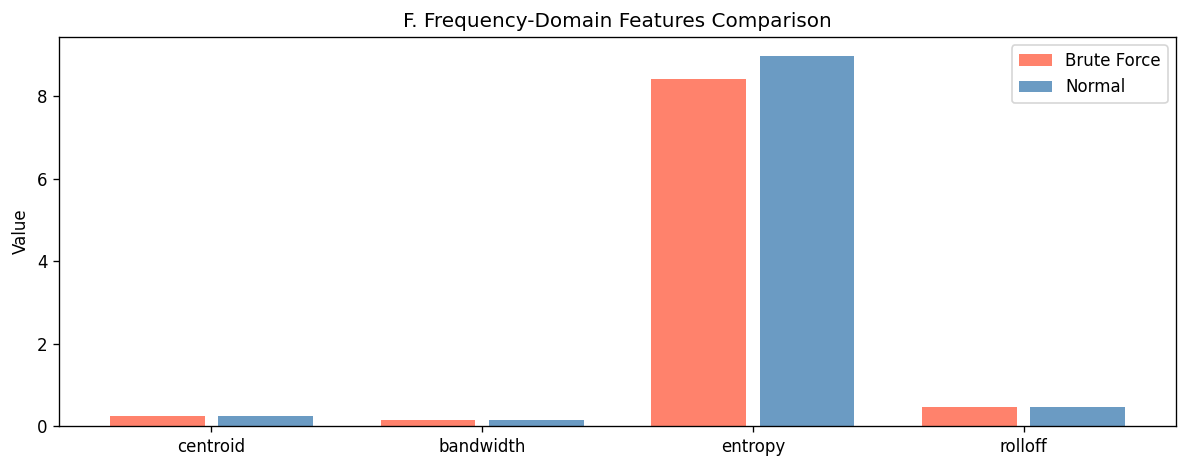

In [ ]:
# Visual summary of spectral features
feat_names = ['centroid', 'bandwidth', 'entropy', 'rolloff']
bf_vals  = [bf_spec[f]  for f in feat_names]
nom_vals = [nom_spec[f] for f in feat_names]

x = np.arange(len(feat_names))
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - 0.2, bf_vals,  0.35, label='Brute Force', color='tomato',    alpha=0.8)
ax.bar(x + 0.2, nom_vals, 0.35, label='Normal',       color='steelblue', alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(feat_names)
ax.set_title('F. Frequency-Domain Features Comparison')
ax.legend(); ax.set_ylabel('Value')
plt.tight_layout()
plt.show()